In [1]:
import pickle
import pathlib

import numpy as np
import pandas as pd
import scipy as sp

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
model_stats_dir = pathlib.Path("../data/scratch/model_stats")

In [3]:
def model_embed_type(ncomp, freeze):
    embed_type = "One-hot"
    if ncomp > 0:
        embed_type = f"PCA dim {ncomp}"
    if freeze:
        embed_type += " : frozen" 
    else:
        embed_type += " : trainable"
    return embed_type

In [4]:
def get_metrics_and_predictions(glob_str="LinearRosettaEnergyPrediction*.pkl"):
    mdf_list = [] # metric dataframes
    pdf_list = [] # predictions dataframes 
    for model_stat_filename in model_stats_dir.glob(glob_str):
        with open(model_stat_filename, "rb") as inp:
            retd = pickle.load(inp)
            mdf = retd["metrics"]
            mdf["num_variants"] = retd["num_variants"]
            embed_type = model_embed_type(retd["embed_ncomp"], retd["embed_freeze"])
            mdf["embed_type"] = embed_type
            mdf_list.append(mdf)

            pdf = pd.DataFrame({'predictions':retd["predictions"], 'values':retd["values"]})
            pdf["num_variants"] = retd["num_variants"]
            pdf["embed_type"] = embed_type
            pdf_list.append(pdf)

    mdf_all = pd.concat(mdf_list) # all the training metrics in a melted dataframe
    pdf_all = pd.concat(pdf_list) # all the predictions in a dataframe

    return mdf_all, pdf_all

## Linear Model

In [5]:
linear_mdf_all, linear_pdf_all = get_metrics_and_predictions("LinearRosettaEnergyPrediction*.pkl")

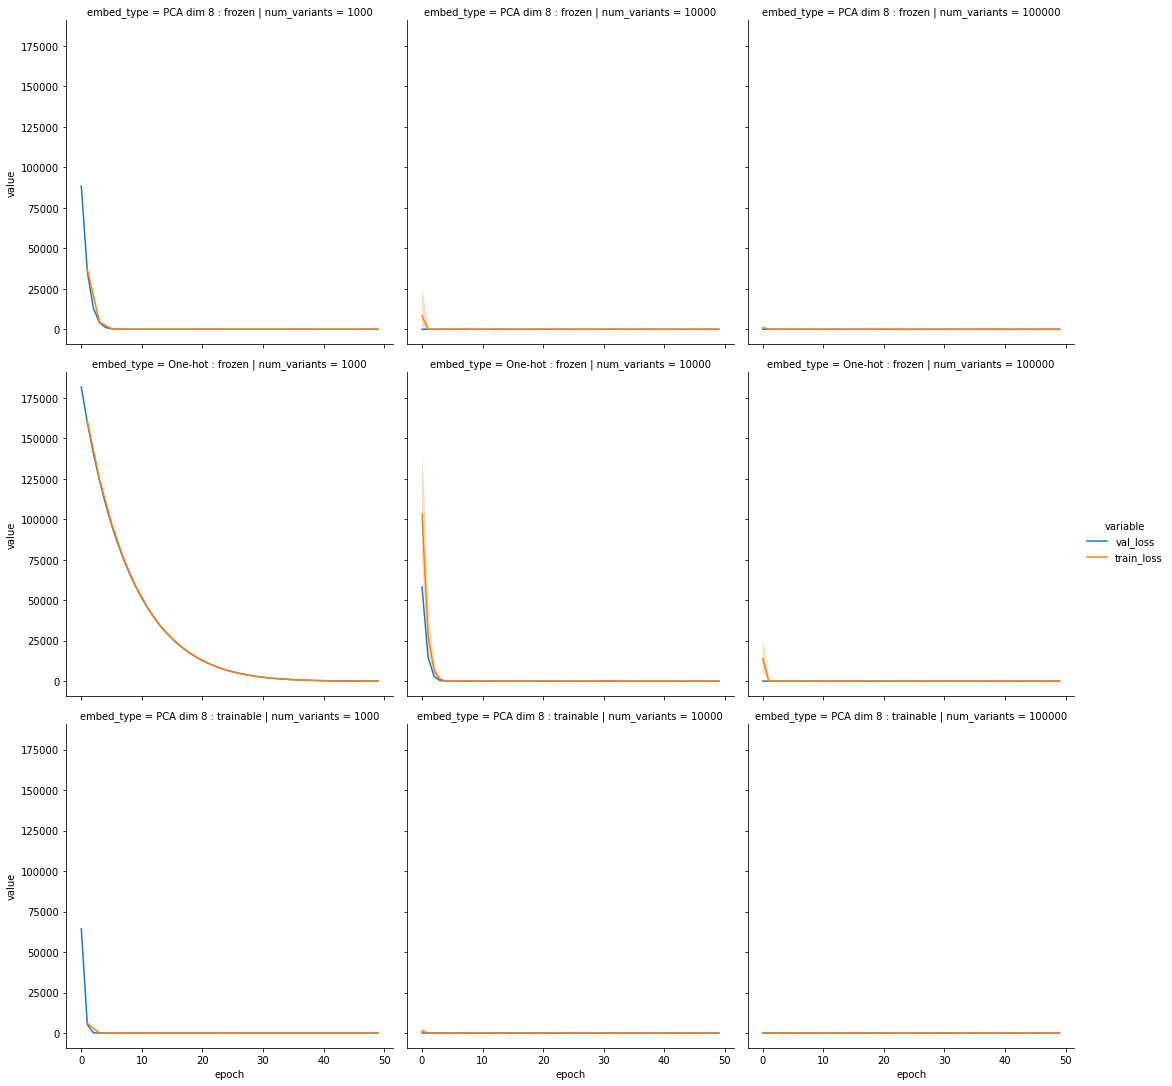

In [6]:
# Loss curves while training Linear Models
g = sns.relplot(x="epoch", y="value", col="num_variants", row="embed_type", 
                hue='variable', data=linear_mdf_all, kind="line")

In [7]:
def annotate_facet_with_correlations(predictions, values, *args, **kwargs):
    pearson_r = sp.stats.pearsonr(predictions, values)
    spearman_r = sp.stats.spearmanr(predictions, values)
    ax = plt.gca()
    ax.text(0.05, 0.9, f"{pearson_r[0]:.2f} : pearson_r\n"
                   f"{spearman_r[0]:.2f}: spearman_r", 
        horizontalalignment='left',
        bbox=dict(boxstyle="round", facecolor='red', alpha=0.5),
        transform=ax.transAxes)

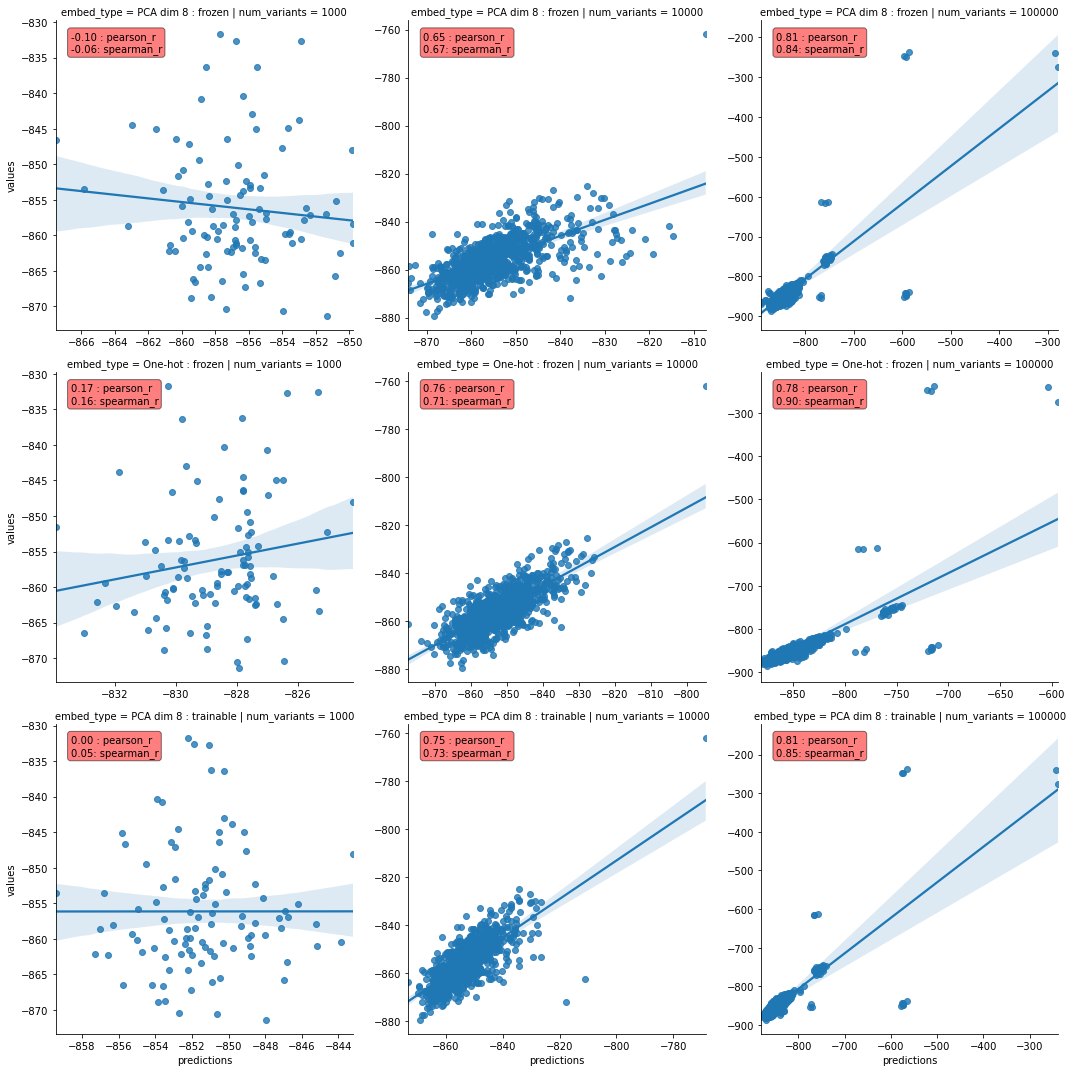

In [8]:
g = sns.lmplot(x="predictions", y="values", col="num_variants", row="embed_type", data=linear_pdf_all,
          sharex=False, sharey=False)
g.map(annotate_facet_with_correlations, "predictions", "values")

## CNN

`kernel_size = 5`

In [9]:
cnn_mdf_all, cnn_pdf_all = get_metrics_and_predictions("CNNRosettaEnergyPrediction*.pkl")

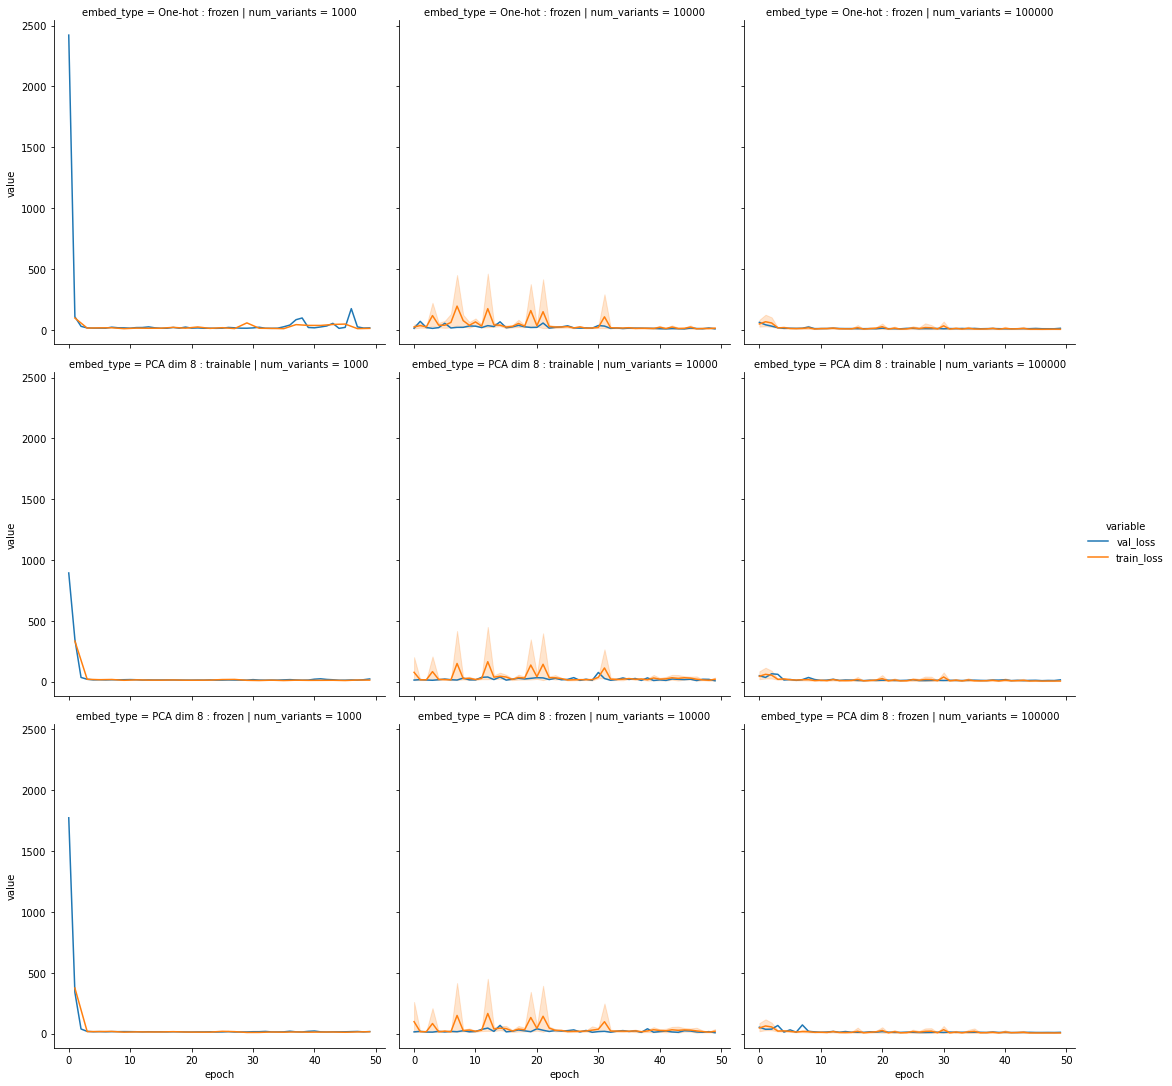

In [10]:
# Loss curves while training CNN Models
g = sns.relplot(x="epoch", y="value", col="num_variants", row="embed_type", 
                hue='variable', data=cnn_mdf_all, kind="line")

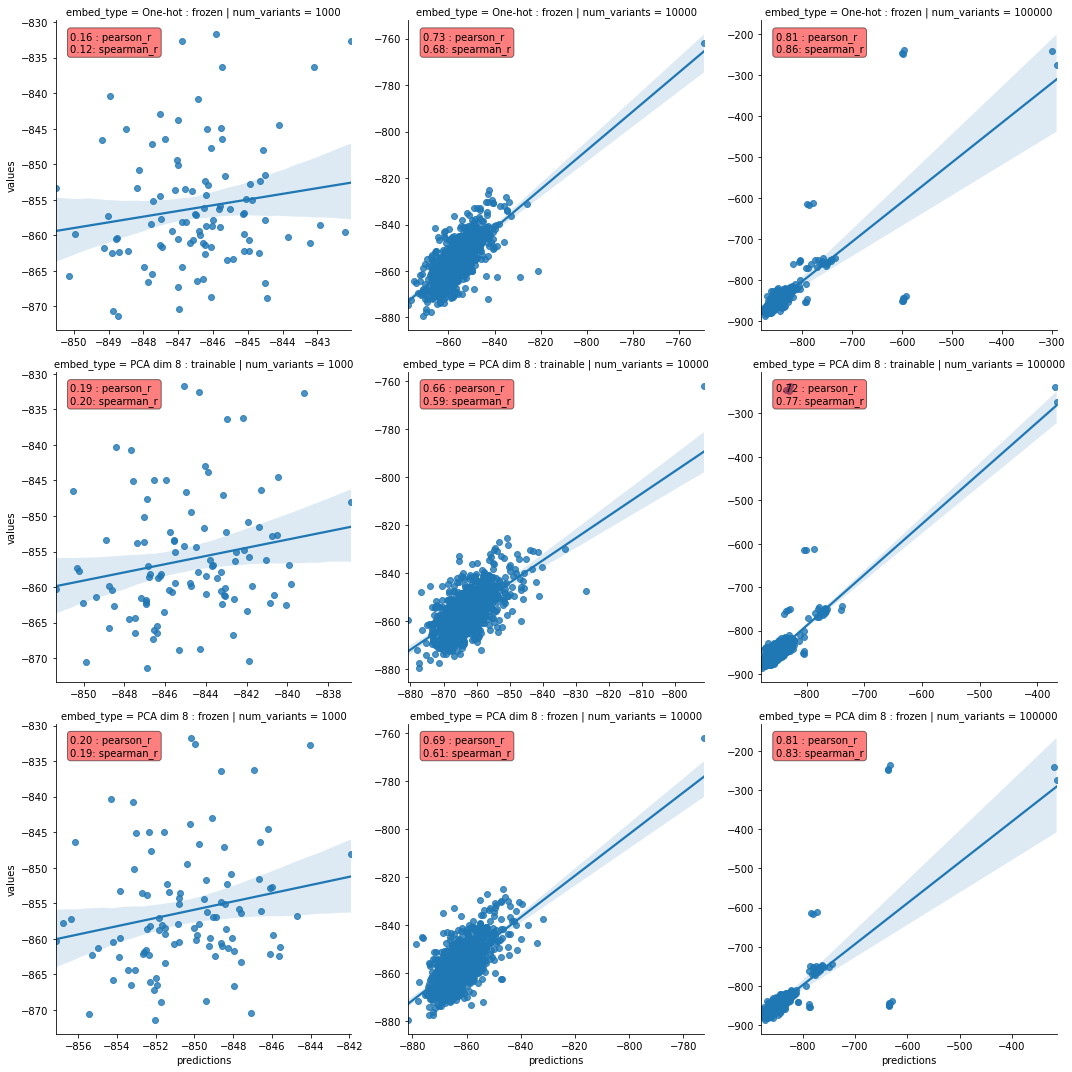

In [11]:
g = sns.lmplot(x="predictions", y="values", col="num_variants", row="embed_type", data=cnn_pdf_all,
          sharex=False, sharey=False)
g.map(annotate_facet_with_correlations, "predictions", "values")